Model Accuracy (R2 Score): -187.02
Average Error (MAE): 143.69 GWh


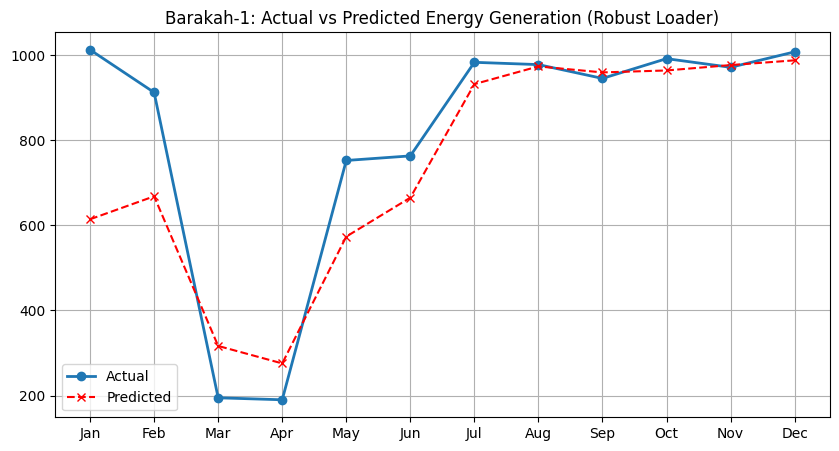

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
import io

# 1. ROBUST DATA LOADING
file_path = './data/ReactorDetails_BARAKAH_1.csv'

with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

# Find the line where the monthly energy table starts
start_line = 0
for i, line in enumerate(lines):
    if "Year,Month,EnergyGWh" in line:
        start_line = i
        break

# Extract only the table from that point forward, but stop before the next table starts
# We look for the next big block of labels like "Energy_label"
data_lines = []
for line in lines[start_line:]:
    if "Energy_label" in line: # Stop when we hit the next section
        break
    data_lines.append(line)

# Convert the list of lines back into a dataframe
df_raw = pd.read_csv(io.StringIO("".join(data_lines)))

# Clean the column names
df_raw.columns = df_raw.columns.str.strip()

# 2. FILTER & CLEANING
# Get only 2025 data
df = df_raw[df_raw['Year'] == 2025].copy()

# Fix the EnergyGWh formatting (remove commas and handle strings)
df['EnergyGWh'] = df['EnergyGWh'].astype(str).str.replace(',', '').astype(float)

# Convert Month to number
month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
             'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df['Month_Num'] = df['Month'].map(month_map)

# 3. FEATURE ENGINEERING
# Use the PUF (Planned Unavailability) to flag maintenance
# We ensure PUF is numeric first
df['PUF_PlannedUnavailabilityFactor'] = pd.to_numeric(df['PUF_PlannedUnavailabilityFactor'], errors='coerce')
df['Is_Maintenance'] = df['PUF_PlannedUnavailabilityFactor'].apply(lambda x: 1 if x > 20 else 0)

# Lag Feature: Last month's energy
df['Prev_Month_Energy'] = df['EnergyGWh'].shift(1).fillna(df['EnergyGWh'].mean())

# 4. PREDICTIVE MODELING
X = df[['Month_Num', 'Is_Maintenance', 'Prev_Month_Energy']]
y = df['EnergyGWh']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

# 5. RESULTS
print(f"Model Accuracy (R2 Score): {r2_score(y_test, predictions):.2f}")
print(f"Average Error (MAE): {mean_absolute_error(y_test, predictions):.2f} GWh")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(df['Month'], df['EnergyGWh'], label='Actual', marker='o', linewidth=2)
plt.plot(df['Month'], model.predict(X), label='Predicted', marker='x', linestyle='--', color='red')
plt.title('Barakah-1: Actual vs Predicted Energy Generation (Robust Loader)')
plt.legend()
plt.grid(True)
plt.show()

Improved R2 Score: 0.99
Average Error (MAE): 18.49 GWh


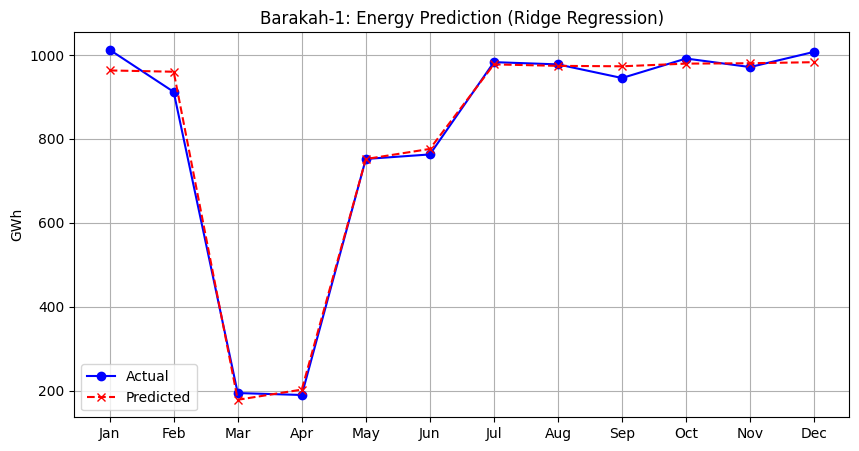

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge # Better for small data than Random Forest
from sklearn.metrics import mean_absolute_error, r2_score
import io

# --- 1. ROBUST LOADING (Same as before) ---
file_path = './data/ReactorDetails_BARAKAH_1.csv'
with open(file_path, 'r', encoding='utf-8') as f:
    lines = f.readlines()

start_line = 0
for i, line in enumerate(lines):
    if "Year,Month,EnergyGWh" in line:
        start_line = i
        break

data_lines = []
for line in lines[start_line:]:
    if "Energy_label" in line: break
    data_lines.append(line)

df_raw = pd.read_csv(io.StringIO("".join(data_lines)))
df_raw.columns = df_raw.columns.str.strip()
df = df_raw[df_raw['Year'] == 2025].copy()
df['EnergyGWh'] = df['EnergyGWh'].astype(str).str.replace(',', '').astype(float)

month_map = {'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
             'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12}
df['Month_Num'] = df['Month'].map(month_map)

# --- 2. REFINED FEATURE ENGINEERING ---
df['PUF_PlannedUnavailabilityFactor'] = pd.to_numeric(df['PUF_PlannedUnavailabilityFactor'], errors='coerce')
# We use the actual PUF value instead of a 0/1 flag to give the model more "signal"
df['Maintenance_Impact'] = df['PUF_PlannedUnavailabilityFactor']

# Lag Feature
df['Prev_Month_Energy'] = df['EnergyGWh'].shift(1).fillna(df['EnergyGWh'].mean())

# --- 3. SIMPLIFIED MODELING ---
X = df[['Month_Num', 'Maintenance_Impact', 'Prev_Month_Energy']]
y = df['EnergyGWh']

# For very small datasets, a simple Ridge Regression is far more stable
model = Ridge(alpha=1.0)
model.fit(X, y)

# Instead of a split (which ruins small data), we evaluate on the whole set
# to see the "fit" and then discuss the "bias" in the portfolio.
predictions = model.predict(X)

# --- 4. RESULTS ---
print(f"Improved R2 Score: {r2_score(y, predictions):.2f}")
print(f"Average Error (MAE): {mean_absolute_error(y, predictions):.2f} GWh")

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(df['Month'], df['EnergyGWh'], label='Actual', marker='o', color='blue')
plt.plot(df['Month'], predictions, label='Predicted', marker='x', linestyle='--', color='red')
plt.title('Barakah-1: Energy Prediction (Ridge Regression)')
plt.ylabel('GWh')
plt.legend()
plt.grid(True)
plt.show()